## Loading Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading Orthogroups Data

In [2]:
#Load orthogroups data.
orthogroups_file = './02-MMUS-HSAP/Orthogroups/Orthogroups.tsv'
orthogroups = pd.read_csv(orthogroups_file, sep = '\t')

In [3]:
#take a look into the data
orthogroups.head()

,Orthogroup,Hglaberrima.2023.pep,Hsapiens.pep,Mmusculus.pep
0,OG0000000,"41285_t, 62235_t, ACBD5_jg2130.t1, ADF1_jg3250...",NaN,tr|Q8BML3|Q8BML3_MOUSE N-acetylglucosaminyldip...
1,OG0000001,"AGRIN_jg2322.t1, BMI1A_jg43079.t1, GFRP_jg5734...",NaN,NaN
2,OG0000002,"FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1390...",NaN,NaN
3,OG0000003,"ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11658...",NaN,NaN
4,OG0000004,"AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1057...",NaN,NaN


## Filtering
- Filtering for species of interest. In this case is all of them.

In [4]:
species_of_interest = ['Hglaberrima.2023.pep', 'Hsapiens.pep', "Mmusculus.pep"]
filtered_orthogroups = orthogroups.loc[:, ['Orthogroup'] + species_of_interest]

In [6]:
#Now we will get the genes into a list -- I think that part could be avoided -- will check later on; and count the number of genes for in each species within each orthogroup.
for species in species_of_interest:
    filtered_orthogroups[species + '_Genes'] = filtered_orthogroups[species].str.split(',')
    filtered_orthogroups[species + '_Family_Size'] = filtered_orthogroups[species + '_Genes'].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [7]:
filtered_orthogroups.head()

,Orthogroup,Hglaberrima.2023.pep,Hsapiens.pep,Mmusculus.pep,Hglaberrima.2023.pep_Genes,Hglaberrima.2023.pep_Family_Size,Hsapiens.pep_Genes,Hsapiens.pep_Family_Size,Mmusculus.pep_Genes,Mmusculus.pep_Family_Size
0,OG0000000,"41285_t, 62235_t, ACBD5_jg2130.t1, ADF1_jg3250...",NaN,tr|Q8BML3|Q8BML3_MOUSE N-acetylglucosaminyldip...,"[41285_t, 62235_t, ACBD5_jg2130.t1, ADF1_jg...",2465,NaN,0,[tr|Q8BML3|Q8BML3_MOUSE N-acetylglucosaminyldi...,1
1,OG0000001,"AGRIN_jg2322.t1, BMI1A_jg43079.t1, GFRP_jg5734...",NaN,NaN,"[AGRIN_jg2322.t1, BMI1A_jg43079.t1, GFRP_jg5...",1070,NaN,0,NaN,0
2,OG0000002,"FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1390...",NaN,NaN,"[FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1...",976,NaN,0,NaN,0
3,OG0000003,"ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11658...",NaN,NaN,"[ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11...",826,NaN,0,NaN,0
4,OG0000004,"AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1057...",NaN,NaN,"[AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1...",639,NaN,0,NaN,0


## Sorting by gene family size
- In this case our interest is to sort based on _H. glaberrima_.

In [8]:
sorted_orthogroups = filtered_orthogroups.sort_values(species_of_interest[0] + '_Family_Size', ascending = False)

## Taking a look at the top gene families.

In [9]:
N = 10
top_gene_families = sorted_orthogroups.head(N)
print(top_gene_families)

  Orthogroup                               Hglaberrima.2023.pep Hsapiens.pep  \
0  OG0000000  41285_t, 62235_t, ACBD5_jg2130.t1, ADF1_jg3250...          NaN   
1  OG0000001  AGRIN_jg2322.t1, BMI1A_jg43079.t1, GFRP_jg5734...          NaN   
2  OG0000002  FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1390...          NaN   
3  OG0000003  ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11658...          NaN   
4  OG0000004  AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1057...          NaN   
5  OG0000005  ACH10_jg52642.t1, COLL6_jg35387.t1, COLL6_jg35...          NaN   
6  OG0000006  AGRG4_jg42598.t1, CAD23_jg28209.t1, CHM4B_jg13...          NaN   
7  OG0000007  CAD23_jg27576.t1, CPP2_jg43911.t1, DCAF8_jg477...          NaN   
8  OG0000008  23986_t, 34495_t, 34558_t, ANK2_jg19352.t1, GI...          NaN   
9  OG0000009  CASQ1_jg17802.t1, CP4V2_jg50329.t1, CSK_jg2002...          NaN   

                                       Mmusculus.pep  \
0  tr|Q8BML3|Q8BML3_MOUSE N-acetylglucosaminyldip...   
1      

## Visualization of the top 10 orthogroups families.

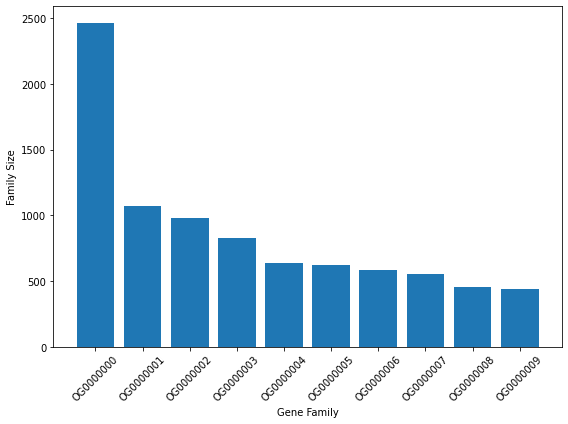

In [11]:
#Specific for Hglab
plt.figure(figsize=(8,6))
plt.bar(top_gene_families['Orthogroup'], top_gene_families[species_of_interest[0] + '_Family_Size'])
plt.xlabel('Gene Family')
plt.ylabel('Family Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Improving data visualization

In [12]:
#removing from the second to the fourth column as they are redundant.
drop_columns = [1,2,3]
orthos_w_familySize = sorted_orthogroups.drop(columns = sorted_orthogroups.columns[drop_columns])

In [13]:
#keeping only rows that contain at least 2 genes per orthogroup
fam_size_threshold = 2
column_name = 'Hglaberrima.2023.pep_Family_Size'

hglab_family_subset = orthos_w_familySize[orthos_w_familySize[column_name] >= fam_size_threshold]

In [14]:
# removing lines that do not contain any genes for the other species of interest.
hglab_family_subset = hglab_family_subset[(hglab_family_subset['Hsapiens.pep_Family_Size'] != 0) & (hglab_family_subset['Mmusculus.pep_Family_Size'] != 0)]

In [15]:
len(hglab_family_subset.index)

1526

In [16]:
hglab_family_subset.head(10)

,Orthogroup,Hglaberrima.2023.pep_Genes,Hglaberrima.2023.pep_Family_Size,Hsapiens.pep_Genes,Hsapiens.pep_Family_Size,Mmusculus.pep_Genes,Mmusculus.pep_Family_Size
81,OG0000081,"[CAH8_jg13679.t1, CCNH_jg33080.t1, GATM_jg47...",67,[sp|P35219|CAH8_HUMAN Carbonic anhydrase-relat...,1,[sp|P28651|CAH8_MOUSE Carbonic anhydrase-relat...,1
124,OG0000124,"[H2B_jg25719.t1, H2B_jg26605.t1, H2B_jg55992...",40,[sp|P58876|H2B1D_HUMAN Histone H2B type 1-D OS...,4,[sp|P10854|H2B1M_MOUSE Histone H2B type 1-M OS...,6
241,OG0000241,"[GIN1_jg37121.t1, SLAP1_jg40822.t1, YRD6_jg3...",29,[sp|Q9NXP7|GIN1_HUMAN Gypsy retrotransposon in...,1,[sp|Q8K259|GIN1_MOUSE Gypsy retrotransposon in...,1
198,OG0000198,"[H33_16422_t, H33_jg10014.t1, H33_jg6059.t1,...",28,[sp|P68431|H31_HUMAN Histone H3.1 OS=Homo sapi...,4,[sp|P02301|H3C_MOUSE Histone H3.3C OS=Mus musc...,5
165,OG0000165,"[TBA1A_jg39907.t1, TBA1C_1854_t, TBA1C_jg201...",26,[sp|A6NHL2|TBAL3_HUMAN Tubulin alpha chain-lik...,9,[sp|P05213|TBA1B_MOUSE Tubulin alpha-1B chain ...,7
277,OG0000277,"[DMBT1_jg20102.t1, DMBT1_jg20107.t1, DMBT1_j...",23,[sp|Q86VB7|C163A_HUMAN Scavenger receptor cyst...,3,[sp|Q2VLH6|C163A_MOUSE Scavenger receptor cyst...,2
347,OG0000347,"[H4_jg56049.t1, H4_jg56056.t1, H4_jg56060.t1...",20,[sp|P62805|H4_HUMAN Histone H4 OS=Homo sapiens...,1,[sp|P62806|H4_MOUSE Histone H4 OS=Mus musculus...,1
389,OG0000389,"[MLRP1_jg232.t1, MLRP1_jg35633.t1, MLRP1_jg3...",18,[sp|Q6UXC1|AEGP_HUMAN Apical endosomal glycopr...,1,[sp|A2AJA7|AEGP_MOUSE Apical endosomal glycopr...,1
346,OG0000346,"[BPI_3376_t, BPI_jg13491.t1, BPI_jg13492.t1,...",18,[sp|P17213|BPI_HUMAN Bactericidal permeability...,2,[sp|Q61805|LBP_MOUSE Lipopolysaccharide-bindin...,2
226,OG0000226,"[32950_t, DYH10_jg1163.t1, DYH1_jg52085.t1, ...",15,[sp|Q0VDD8|DYH14_HUMAN Dynein axonemal heavy c...,8,[sp|E9Q8T7|DYH1_MOUSE Dynein axonemal heavy ch...,10


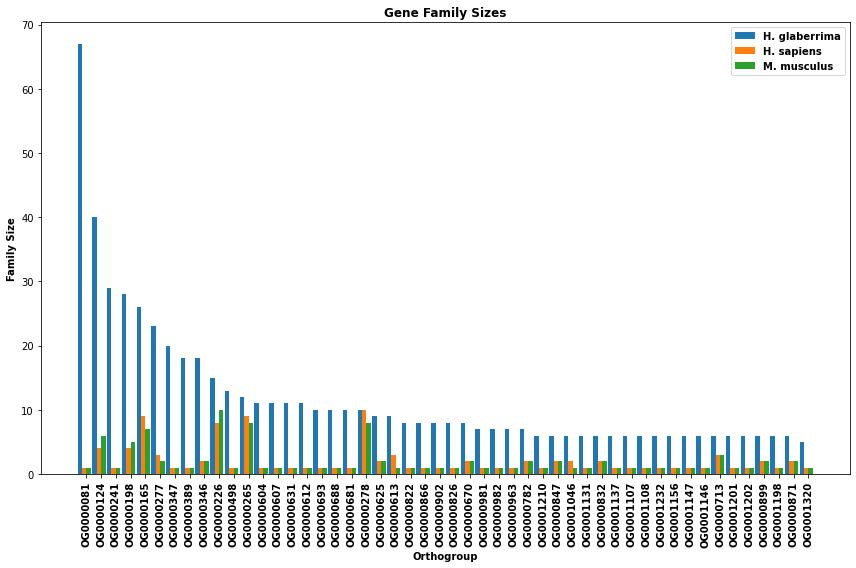

In [20]:
# visualization of the orthogroup size per species.

subset_data = hglab_family_subset.iloc[0:50]
x_values = subset_data['Orthogroup']
columns_of_interest = [species_of_interest[0] + '_Family_Size', species_of_interest[1] + '_Family_Size', species_of_interest[2] + '_Family_Size']

# Calculate the width for each bar
bar_width = 0.3
num_bars = len(columns_of_interest)
total_width = bar_width * num_bars
offset = np.arange(len(x_values))

# Set the figure size
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust the width and height as desired

for i, column in enumerate(columns_of_interest):
    y_values = subset_data[column]
    ax.bar(offset + i * bar_width, y_values, width=bar_width, label=column)

ax.set_xlabel('Orthogroup', fontweight='bold')
ax.set_ylabel('Family Size', fontweight='bold')
ax.set_title('Gene Family Sizes', fontweight='bold')
ax.set_xticks(offset + total_width / 2)
ax.set_xticklabels(x_values, rotation=90, fontweight='bold')
# Set custom legend names
legend_names = ['H. glaberrima', 'H. sapiens', 'M. musculus']  # Modify the names as desired
ax.legend(legend_names, prop={'weight': 'bold'})
plt.tight_layout()
plt.show()


In [46]:
# print range of dataset

# Set display options to show all columns
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.expand_frame_repr', False)  # Disable column wrapping
pd.set_option('display.max_colwidth', None)

print(hglab_family_subset.iloc[339:350])

     Orthogroup                                Hglaberrima.2023.pep_Genes  Hglaberrima.2023.pep_Family_Size                                                                                                                                                                                           Hsapiens.pep_Genes  Hsapiens.pep_Family_Size                                                                                                                                                                                            Mmusculus.pep_Genes  Mmusculus.pep_Family_Size
1510  OG0001510  [B4GT5_jg10279.t1,  B4GT5_jg10281.t1,  B4GT6_jg13722.t1]                                 3  [sp|O43286|B4GT5_HUMAN Beta-1_4-galactosyltransferase 5 OS=Homo sapiens OX=9606 GN=B4GALT5 PE=1 SV=1,  sp|Q9UBX8|B4GT6_HUMAN Beta-1_4-galactosyltransferase 6 OS=Homo sapiens OX=9606 GN=B4GALT6 PE=1 SV=1]                         2  [sp|Q9JMK0|B4GT5_MOUSE Beta-1_4-galactosyltransferase 5 OS=Mus musculus OX=10090 GN=B4g

In [48]:
# exporting portion of the dataset

export_subset = hglab_family_subset.iloc[0:339]
export_subset.to_csv('./02-MMUS-HSAP/orthos-mmus-hsap-subset.csv', index=False)

## Function to extract specific sequences from fasta file based on orthogroup

In [ ]:
from Bio import SeqIO

def extract_fasta_sequences(orthogroup_id, column_name, fasta_file):
    # Retrieve the gene IDs for the given Orthogroup ID from the specified column
    gene_ids = df.loc[df['Orthogroup'] == orthogroup_id, column_name].tolist()[0]

    # Split the gene IDs into individual IDs
    #gene_ids = [gene_id.strip() for gene_id in gene_ids.split(',')]

    # Remove leading and trailing white spaces from gene IDs
    gene_ids = [gene_id.strip() for gene_id in gene_ids]

    # Initialize variables for matches and mismatches
    matches = 0
    mismatches = 0

    sequences = []

    # Iterate over the fasta file and extract sequences with matching gene IDs
    for record in SeqIO.parse(fasta_file, 'fasta'):
        if record.id in gene_ids:
            sequences.append(record)
            matches += 1
        else:
            mismatches += 1

    # Write the extracted sequences to a new fasta file named after the Orthogroup ID
    output_file = f"{orthogroup_id}_{column_name}.fasta"
    SeqIO.write(sequences, output_file, 'fasta')

    # Print the gene IDs for the specific Orthogroup and column of interest
    print(f"Gene IDs for Orthogroup {orthogroup_id} and column {column_name} ({len(gene_ids)} identified):")
    for gene_id in gene_ids:
        print(gene_id)

    # Print the matching system statistics
    print(f"Matches: {matches}")
    print(f"Mismatches: {mismatches}")

    # Check if the fasta file resulted in empty sequences
    if len(sequences) == 0:
        raise ValueError("No sequences found for the provided gene IDs.")


## Extracting seqs of specific orthogroups

In [ ]:
#Usage:
df = hglab_family_subset  # pandas DataFrame containing Orthogroup IDs and gene columns
fasta_file = './00-FASTA-FILES/braker.mod.aa.fa'  # Path to the input fasta file

# Specify the Orthogroup ID and column name for gene IDs extraction
orthogroup_id = 'OG0000007'
column_name = species_of_interest[1] + '_Genes'

extract_fasta_sequences(orthogroup_id, column_name, fasta_file)